# Bước 1 — EDA: SAVVY-2BT inventory

**Mục tiêu của notebook này** (theo `ROADMAP.md` §3 Bước 1):

1. Hiểu schema: dtypes, missing, duplicates → biết phải clean gì ở `src/data.py`.
2. Đếm cardinality: bao nhiêu hotel, room_type → quyết định dropdown trong app + có bao nhiêu series cần fit SARIMA.
3. Derive `lead_time` và xem phân phối → biến giải thích quan trọng nhất.
4. Plot price/occupancy theo thời gian → có pattern theo dow / mùa không?
5. **Sanity check biến động giá** trong cùng `(hotel, room_type, stay_date)` — đây là câu hỏi lớn nhất: nếu giá gần như cố định trên tất cả snapshot, demand model sẽ KHÔNG học được elasticity (xem ROADMAP §3 Bước 4 caveat).
6. Feasibility cho SARIMA: mỗi `(hotel, room_type)` có chuỗi đủ dài (≥60–90 ngày stay_date) không?

**Deliverable cuối notebook**: 5–8 bullet insight để dẫn vào Bước 2 (feature engineering).

---

> 📝 *Mỗi section có markdown giải thích Why trước rồi code. Đọc tuần tự từ trên xuống, chạy từng cell và quan sát output.*

## 1. Setup — imports & path

**Why**: Notebook nằm trong `notebooks/`, nhưng code production nằm trong `src/`. Để import được `src.data.load_raw`, ta cần add project root vào `sys.path`. Đây là pattern chuẩn cho dự án Python có cấu trúc `src/` package.

Import gì:
- `pandas` / `numpy`: core data manipulation.
- `matplotlib.pyplot`: plotting cho EDA (Streamlit app mới dùng Plotly — không cần ở EDA).
- `pathlib.Path` để xử lý đường dẫn portable.
- `%matplotlib inline` để plot hiển thị ngay trong notebook.

In [1]:
from pathlib import Path
import sys

# Add project root vào sys.path để import được package `src`
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100

# Print nhiều cột hơn khi df.head()
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)

print('pandas', pd.__version__, '| numpy', np.__version__)
print('PROJECT_ROOT =', PROJECT_ROOT)

pandas 2.3.3 | numpy 1.26.4
PROJECT_ROOT = /Users/puppy/Desktop/AI-Course/projects/dynamic-pricing/.claude/worktrees/dazzling-lamport-a0d077


## 2. Load CSV qua `src/data.py`

**Why dùng `src.data.load_raw` thay vì gọi thẳng `pd.read_csv`?**

- Single source of truth: production code (`src/forecast.py`, `app/streamlit_app.py`) và notebook đều load qua cùng 1 hàm → khi schema CSV đổi, chỉ cần sửa 1 chỗ.
- `load_raw` đã set `parse_dates=['updated_date', 'date']` → 2 cột date được parse thành `datetime64` ngay khi load, tránh quên parse rồi tính `lead_time` ra giá trị sai.

Output mong đợi: DataFrame ~55,225 dòng × 13 cột (theo ROADMAP §1).

In [2]:
from src.data import load_raw

df = load_raw()
print('shape:', df.shape)
df.head()

shape: (55225, 13)


,updated_date,date,hotel_id,hotel_name,room_type_name,total_booked,total_maintenance,total,available,price,ota_price,room_type_segment,brand_sub_segment
0,2026-05-04,2026-05-04,956,SAVVY BY M VILLAGE HAI BÀ TRƯNG,Deluxe with banquette seating,4,0,10,6,1500000.0,3900000.0,Entry,Savvy-HCM
1,2026-05-04,2026-05-07,956,SAVVY BY M VILLAGE HAI BÀ TRƯNG,Superior City View,8,0,12,4,1700000.0,4420000.0,Entry,Savvy-HCM
2,2026-05-04,2026-05-10,956,SAVVY BY M VILLAGE HAI BÀ TRƯNG,Superior City View,7,0,12,5,1700000.0,4420000.0,Entry,Savvy-HCM
3,2026-05-04,2026-05-05,956,SAVVY BY M VILLAGE HAI BÀ TRƯNG,Superior City View,8,0,12,4,1700000.0,4420000.0,Entry,Savvy-HCM
4,2026-05-04,2026-05-08,956,SAVVY BY M VILLAGE HAI BÀ TRƯNG,Deluxe with banquette seating,2,0,10,8,1800000.0,4680000.0,Entry,Savvy-HCM


### 2.1. Schema: dtypes

Check `updated_date` và `date` đã thành `datetime64[ns]`. Các cột số (`total`, `price`, ...) phải là `int64`/`float64`, không phải `object` (string). Nếu có cột số bị parse thành object → trong CSV có giá trị lạ (string, dấu phẩy, ...) → cần handle ở `src/data.clean`.

In [3]:
df.dtypes

updated_date         datetime64[ns]
date                 datetime64[ns]
hotel_id                      int64
hotel_name                   object
room_type_name               object
total_booked                  int64
total_maintenance             int64
total                         int64
available                     int64
price                       float64
ota_price                   float64
room_type_segment            object
brand_sub_segment            object
dtype: object

## 3. Data quality: missing & duplicates

**Why kiểm tra missing?** Nếu cột `price` thiếu nhiều → mất data point để train. Nếu `total_booked` thiếu → không tính được occupancy. Tuỳ cột mà cách xử lý khác nhau: `price` NaN có thể là ngày phòng đóng → drop; `ota_price` NaN có thể là chưa publish lên OTA → impute hoặc bỏ feature đó.

**Why duplicates?** Dataset là snapshot — về lý mỗi `(updated_date, hotel_id, room_type_name, date)` chỉ có 1 dòng. Nếu trùng → có thể do export 2 lần, hoặc có chiều phân biệt khác mình chưa nhận ra.

In [4]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)

,missing_count,missing_pct
updated_date,0,0.0
date,0,0.0
hotel_id,0,0.0
hotel_name,0,0.0
room_type_name,0,0.0
total_booked,0,0.0
total_maintenance,0,0.0
total,0,0.0
available,0,0.0
price,0,0.0


In [5]:
# Duplicate toàn dòng
n_full_dup = df.duplicated().sum()

# Duplicate trên key logic (cùng snapshot + stay + room)
key = ['updated_date', 'hotel_id', 'room_type_name', 'date']
n_key_dup = df.duplicated(subset=key).sum()

print(f'Trùng toàn dòng        : {n_full_dup}')
print(f'Trùng theo key {key}: {n_key_dup}')

Trùng toàn dòng        : 0
Trùng theo key ['updated_date', 'hotel_id', 'room_type_name', 'date']: 0


## 4. Cardinality: số hotel, room_type, segment

**Why**: ROADMAP §1 đặt câu hỏi *"CSV này có bao nhiêu hotel? Sample chỉ thấy 1 hotel (SAVVY HBT)"*. Trả lời câu này quyết định:

- Dropdown chi nhánh trong Streamlit app có 1 hay nhiều lựa chọn.
- Số series SARIMA phải fit = `n_hotel × n_room_type`. Nhiều series → cần multi-process khi train (sau).
- Có nên gộp model theo `room_type_segment` (Standard / Deluxe / Suite) nếu room_type quá manh mún.

In [6]:
for col in ['hotel_id', 'hotel_name', 'room_type_name', 'room_type_segment', 'brand_sub_segment']:
    n = df[col].nunique(dropna=False)
    print(f'{col:25s} unique = {n}')

print('\n--- hotel breakdown ---')
print(df.groupby(['hotel_id', 'hotel_name'], dropna=False).size().rename('rows').reset_index())

print('\n--- room_type x segment ---')
print(df.groupby(['room_type_segment', 'room_type_name'], dropna=False).size().rename('rows').reset_index())

hotel_id                  unique = 1
hotel_name                unique = 1
room_type_name            unique = 5
room_type_segment         unique = 3
brand_sub_segment         unique = 1

--- hotel breakdown ---
   hotel_id                       hotel_name   rows
0       956  SAVVY BY M VILLAGE HAI BÀ TRƯNG  55225

--- room_type x segment ---
  room_type_segment                           room_type_name   rows
0             Entry            Deluxe with banquette seating   6031
1             Entry                       Superior City View  11045
2              High  Deluxe City View with banquette seating  11045
3              High                        Premier city view  11045
4               Mid                    Deluxe City View Room  11045
5               Mid            Deluxe with banquette seating   5014


## 5. Date ranges + derive `lead_time`

**Why lead_time là biến quan trọng nhất?**

Trong hotel pricing, càng gần ngày ở (lead_time nhỏ) thì:
- Khách ít option hơn, có xu hướng book gấp → revenue manager hay đẩy giá lên.
- Hoặc ngược lại: phòng còn trống, giảm giá kích cầu (last-minute discount).

Cả 2 chiều đều xảy ra trong thực tế tuỳ chiến lược — và đó chính là cái demand model cần học. Vì vậy `lead_time` xuất hiện ở cả forecast (gián tiếp qua snapshot policy) và demand model (trực tiếp như feature).

Công thức: `lead_time_days = (date − updated_date)` tính bằng ngày.
- `lead_time = 0` → snapshot chụp đúng ngày khách ở (walk-in).
- `lead_time = 30` → snapshot chụp 30 ngày trước stay date.
- `lead_time < 0` → bug data (snapshot "sau" ngày ở — không hợp lý).

In [7]:
print('updated_date range:', df['updated_date'].min(), '→', df['updated_date'].max(),
      f"({(df['updated_date'].max() - df['updated_date'].min()).days} days)")
print('stay_date range   :', df['date'].min(), '→', df['date'].max(),
      f"({(df['date'].max() - df['date'].min()).days} days)")

# Derive lead_time
df['lead_time_days'] = (df['date'] - df['updated_date']).dt.days

print('\nlead_time_days describe:')
print(df['lead_time_days'].describe())

neg = (df['lead_time_days'] < 0).sum()
print(f"\nSố dòng có lead_time âm (bất thường): {neg} ({neg/len(df)*100:.2f}%)")

updated_date range: 2026-01-02 00:00:00 → 2026-05-04 00:00:00 (122 days)
stay_date range   : 2026-01-01 00:00:00 → 2026-07-30 00:00:00 (210 days)

lead_time_days describe:
count    55225.000000
mean        30.187053
std         27.390240
min        -30.000000
25%          8.000000
50%         30.000000
75%         53.000000
max         90.000000
Name: lead_time_days, dtype: float64

Số dòng có lead_time âm (bất thường): 8745 (15.84%)


### 5.1. Histogram `lead_time`

Mong đợi: phân phối lệch phải (right-skewed). Booking window thường tập trung ở 0–30 ngày (short-haul) với tail dài đến vài tháng.

Nếu thấy phân phối khác lạ (vd: 2 đỉnh) → có thể policy ngắt snapshot theo 2 tier khác nhau, cần đào sâu.

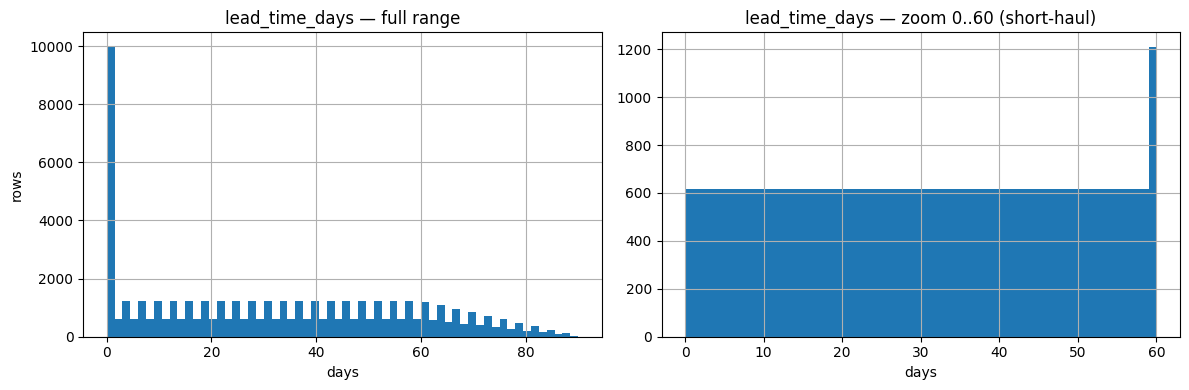

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['lead_time_days'].clip(lower=0).hist(bins=60, ax=axes[0])
axes[0].set_title('lead_time_days — full range')
axes[0].set_xlabel('days')
axes[0].set_ylabel('rows')

df.loc[df['lead_time_days'].between(0, 60), 'lead_time_days'].hist(bins=60, ax=axes[1])
axes[1].set_title('lead_time_days — zoom 0..60 (short-haul)')
axes[1].set_xlabel('days')

plt.tight_layout(); plt.show()

## 6. Price — describe & breakdown theo room_type

**Why split theo room_type**: giá Deluxe khác Standard cả triệu — nếu nhìn distribution toàn bộ thì sẽ thấy bimodal (2 đỉnh). Tách ra mới đọc được nhịp giá thật của từng loại.

Cũng nên check `price` và `ota_price` lệch nhau bao nhiêu — nếu OTA cao hơn direct rõ rệt thì chiến lược đã có sẵn (channel pricing); model dynamic pricing của ta focus vào `price` direct.

In [9]:
print('--- price (direct) ---')
print(df['price'].describe())
print('\n--- ota_price ---')
print(df['ota_price'].describe())

# price = 0 thường = phòng close / không bán → cần handle ở clean
n_zero = (df['price'] == 0).sum()
print(f"\nprice == 0: {n_zero} ({n_zero/len(df)*100:.2f}%)")

--- price (direct) ---
count    5.522500e+04
mean     2.980573e+06
std      4.954046e+05
min      1.500000e+06
25%      2.600000e+06
50%      2.950000e+06
75%      3.300000e+06
max      5.050000e+06
Name: price, dtype: float64

--- ota_price ---
count    5.522500e+04
mean     7.754108e+06
std      1.287071e+06
min      3.900000e+06
25%      6.760000e+06
50%      7.750000e+06
75%      8.580000e+06
max      1.313000e+07
Name: ota_price, dtype: float64

price == 0: 0 (0.00%)


In [10]:
df.groupby('room_type_name')['price'].describe().round(0)

,count,mean,std,min,25%,50%,75%,max
room_type_name,,,,,,,,
Deluxe City View Room,11045.0,2891888.0,350666.0,1900000.0,2700000.0,2900000.0,3100000.0,4350000.0
Deluxe City View with banquette seating,11045.0,3088533.0,345424.0,2000000.0,2900000.0,3100000.0,3300000.0,4550000.0
Deluxe with banquette seating,11045.0,2780249.0,380913.0,1500000.0,2500000.0,2700000.0,3000000.0,4350000.0
Premier city view,11045.0,3579792.0,350747.0,2400000.0,3400000.0,3600000.0,3800000.0,5050000.0
Superior City View,11045.0,2562404.0,350974.0,1600000.0,2400000.0,2600000.0,2700000.0,3950000.0


## 7. Price theo thời gian (line chart)

**Why phải chọn 1 giá đại diện per stay_date trước khi plot?**

Trong panel data này, mỗi stay_date có nhiều dòng (mỗi `updated_date` 1 snapshot). Nếu plot luôn thì line sẽ rối. Convention (sẽ dùng lại ở Bước 3 cho SARIMA): **lấy snapshot mới nhất** — tức giá "chốt" gần stay_date nhất, thường là giá khách thực sự thấy lúc book.

Pattern mong đợi:
- Weekly seasonality: weekend cao hơn weekday (du lịch ngắn ngày).
- Holiday spikes: 30/4, 2/9, Tết.
- Trend dài hạn nếu có (chính sách giá thay đổi).

latest shape: (1055, 14)


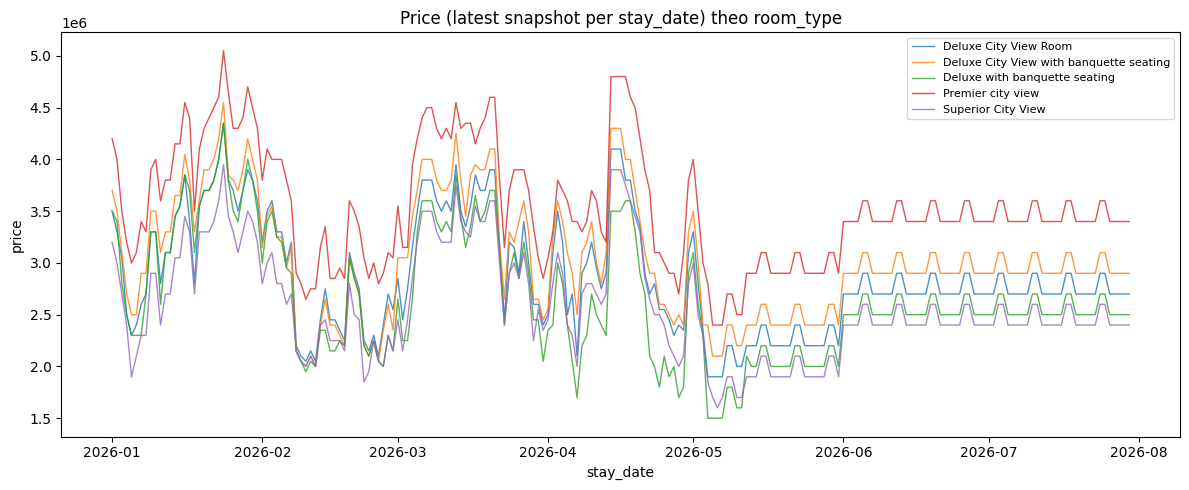

In [11]:
# Snapshot mới nhất per (hotel, room_type, stay_date)
latest = (df.sort_values('updated_date')
            .groupby(['hotel_id', 'room_type_name', 'date'], as_index=False)
            .tail(1))

print('latest shape:', latest.shape)

fig, ax = plt.subplots(figsize=(12, 5))
for room_type, g in latest.groupby('room_type_name'):
    g_sorted = g.sort_values('date')
    ax.plot(g_sorted['date'], g_sorted['price'], label=room_type, alpha=0.8, linewidth=1)

ax.set_title('Price (latest snapshot per stay_date) theo room_type')
ax.set_xlabel('stay_date'); ax.set_ylabel('price')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

## 8. Occupancy theo thời gian

**Why**: occupancy_pct = `total_booked / total` là tín hiệu "phòng đang cháy hay ế". Mục tiêu nhìn:
- Có ngày nào full (=1.0) không? → constraint cứng (không bán thêm được).
- Pattern weekly + seasonal có giống price không?

Cẩn thận: chia cho `total` có thể = 0 → NaN. Filter `total > 0` trước.

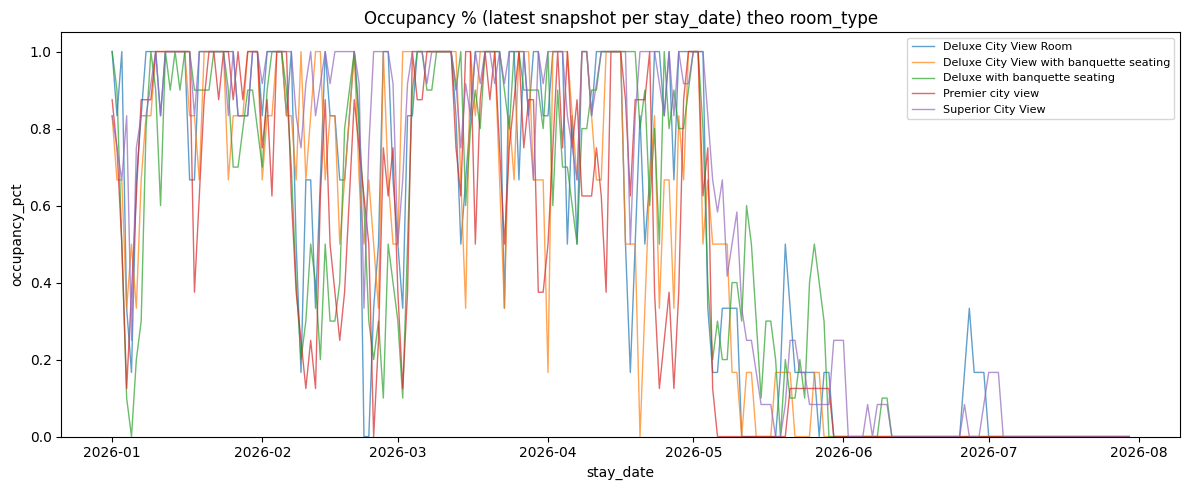

In [12]:
latest = latest.assign(
    occupancy_pct=np.where(latest['total'] > 0, latest['total_booked'] / latest['total'], np.nan)
)

fig, ax = plt.subplots(figsize=(12, 5))
for room_type, g in latest.groupby('room_type_name'):
    g_sorted = g.sort_values('date')
    ax.plot(g_sorted['date'], g_sorted['occupancy_pct'], label=room_type, alpha=0.7, linewidth=1)

ax.set_title('Occupancy % (latest snapshot per stay_date) theo room_type')
ax.set_xlabel('stay_date'); ax.set_ylabel('occupancy_pct')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

## 9. Scatter / boxplot: cross-signal giữa price và các biến

**Why**: tìm nhanh relationship dạng "price cao khi X cao/thấp". 3 plot quan trọng:

1. **price vs lead_time** — kỳ vọng có xu hướng tăng/giảm khi lead_time đổi (last-minute pricing).
2. **price vs occupancy** — kỳ vọng dương: phòng đầy → giá cao.
3. **price vs day_of_week** — weekend nên cao hơn weekday.

Nếu KHÔNG thấy quan hệ rõ → hoặc data noisy, hoặc revenue manager đang đặt giá khá tĩnh.

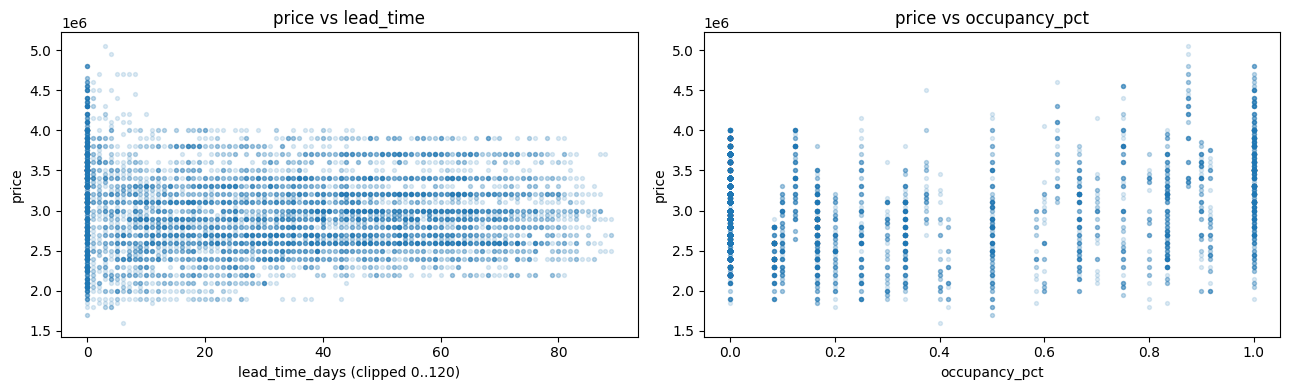

In [13]:
# Subsample cho scatter nhanh
sample = df.sample(min(8000, len(df)), random_state=42)
sample = sample.assign(
    occupancy_pct=np.where(sample['total'] > 0, sample['total_booked'] / sample['total'], np.nan)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(sample['lead_time_days'].clip(0, 120), sample['price'], alpha=0.15, s=8)
axes[0].set_xlabel('lead_time_days (clipped 0..120)'); axes[0].set_ylabel('price')
axes[0].set_title('price vs lead_time')

axes[1].scatter(sample['occupancy_pct'], sample['price'], alpha=0.15, s=8)
axes[1].set_xlabel('occupancy_pct'); axes[1].set_ylabel('price')
axes[1].set_title('price vs occupancy_pct')

plt.tight_layout(); plt.show()

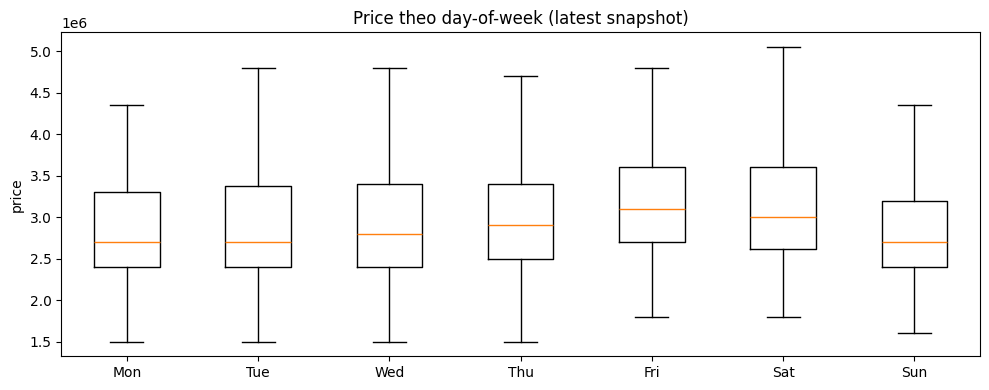

In [14]:
# Boxplot price theo day-of-week (dùng latest để giảm noise từ snapshot)
latest = latest.assign(dow=latest['date'].dt.dayofweek)
dow_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(10, 4))
data_by_dow = [latest.loc[latest['dow'] == d, 'price'].dropna().values for d in range(7)]
ax.boxplot(data_by_dow, tick_labels=dow_names, showfliers=False)
ax.set_title('Price theo day-of-week (latest snapshot)'); ax.set_ylabel('price')
plt.tight_layout(); plt.show()

## 10. Correlation matrix (numerical features)

**Why**: nhìn nhanh các cặp tương quan mạnh. Cẩn thận:
- Correlation chỉ đo quan hệ tuyến tính → có thể miss non-linear pattern (sẽ dùng LightGBM ở demand model để bắt).
- High corr giữa 2 feature input (vd `total_booked` ~ `occupancy_pct`) → cần tránh đưa cả 2 vào model tuyến tính (multicollinearity).

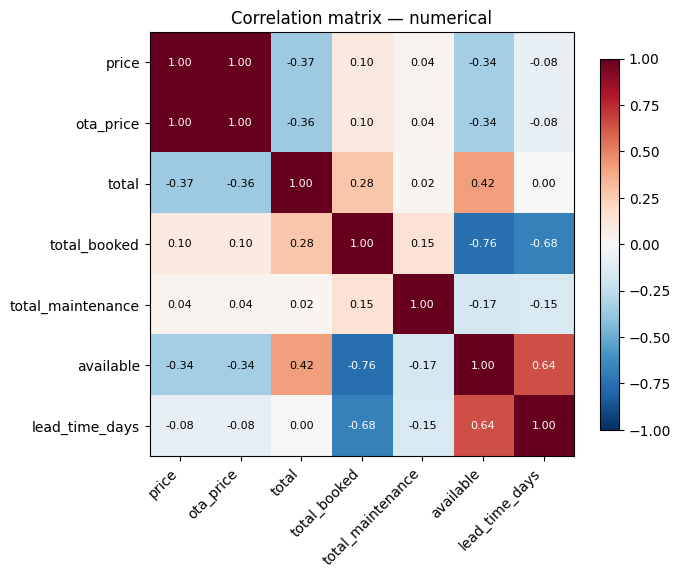

In [15]:
num_cols = ['price', 'ota_price', 'total', 'total_booked', 'total_maintenance', 'available', 'lead_time_days']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.values[i, j]) > 0.5 else 'black', fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation matrix — numerical')
plt.tight_layout(); plt.show()

## 11. Heatmap (day_of_week × lead_time_bucket) → mean price

**Why**: 2D view của 2 biến signal-mạnh-nhất. Nếu thấy cell weekend × short-lead có giá đậm hơn rõ rệt → bằng chứng cho thấy revenue manager đang dynamic pricing → demand model có hope học được elasticity.

Bucket lead_time giống định nghĩa sẽ dùng ở `src/features.py` (Bước 2).

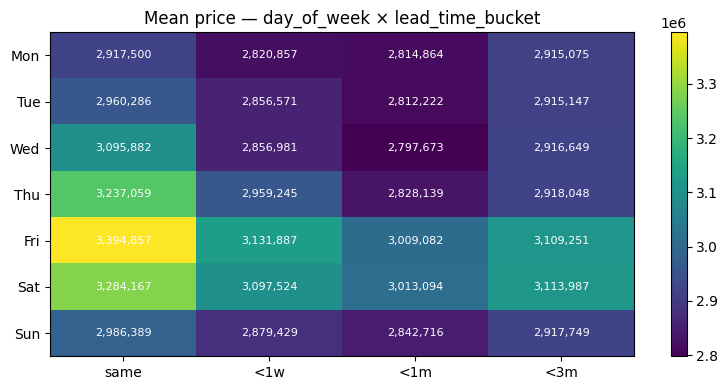

In [16]:
df_tmp = df.assign(
    dow=df['date'].dt.dayofweek,
    lead_bucket=pd.cut(df['lead_time_days'], bins=[-1, 1, 7, 30, 90, 365],
                       labels=['same', '<1w', '<1m', '<3m', '>3m'])
)
pivot = df_tmp.pivot_table(index='dow', columns='lead_bucket', values='price',
                            aggfunc='mean', observed=True)
pivot.index = dow_names

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pivot.values, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:,.0f}', ha='center', va='center', color='white', fontsize=8)
fig.colorbar(im, ax=ax)
ax.set_title('Mean price — day_of_week × lead_time_bucket')
plt.tight_layout(); plt.show()

## 12. ⚡ KEY CHECK — Biến động giá per `(hotel, room_type, stay_date)`

**Đây là check quan trọng nhất của Bước 1.** ROADMAP §3 Bước 4 cảnh báo:

> *"Trong cùng `(hotel, room_type, stay_date)`, price có thay đổi theo `updated_date` không? Nếu giá gần như cố định → demand model khó học elasticity."*

**Logic**: với mỗi tổ hợp `(hotel, room_type, stay_date)`, ta có nhiều snapshot (mỗi `updated_date` 1 snapshot). Nếu giá KHÔNG đổi giữa các snapshot → ta chỉ có 1 quan sát giá cho mỗi context → không thể học "nếu đổi giá thì P(book) đổi sao" (counterfactual missing).

**Cách đo**:
- Per group, tính `n_snapshots`, `n_unique_prices`, `price_std`, `price_range = max - min`.
- Sau đó plot phân phối `n_unique_prices` và `price_range / price_mean` (coefficient of variation).

**Phán đoán**:
- Nếu **>50% group có `n_unique_prices == 1`** → giá cứng → demand model sẽ rất yếu, cần ghi rõ trong README và Phase 2 phải A/B test thật.
- Nếu nhiều group có ≥3 mức giá khác nhau → có signal để học.

In [17]:
group_keys = ['hotel_id', 'room_type_name', 'date']

g = df.groupby(group_keys)['price']
variation = pd.DataFrame({
    'n_snapshots': g.size(),
    'n_unique_prices': g.nunique(),
    'price_mean': g.mean(),
    'price_std': g.std().fillna(0),
    'price_range': g.max() - g.min(),
})
variation['cv'] = variation['price_std'] / variation['price_mean'].replace(0, np.nan)

print(f'Tổng số group (hotel, room_type, stay_date): {len(variation):,}')
print(f'\nPhân phối n_unique_prices per group:')
print(variation['n_unique_prices'].value_counts().sort_index().head(15))

pct_flat = (variation['n_unique_prices'] == 1).mean() * 100
pct_2 = (variation['n_unique_prices'] == 2).mean() * 100
pct_3plus = (variation['n_unique_prices'] >= 3).mean() * 100
print(f'\n→ Giá CỐ ĐỊNH (1 unique)            : {pct_flat:5.1f}%')
print(f'→ Giá đổi 2 mức                     : {pct_2:5.1f}%')
print(f'→ Giá đổi ≥3 mức (có signal tốt)    : {pct_3plus:5.1f}%')

print(f'\nprice_range describe:')
print(variation['price_range'].describe().round(0))

Tổng số group (hotel, room_type, stay_date): 1,055

Phân phối n_unique_prices per group:
n_unique_prices
1     315
2      30
3      53
4     103
5     129
6     144
7     130
8      86
9      49
10      7
11      5
12      2
13      2
Name: count, dtype: int64

→ Giá CỐ ĐỊNH (1 unique)            :  29.9%
→ Giá đổi 2 mức                     :   2.8%
→ Giá đổi ≥3 mức (có signal tốt)    :  67.3%

price_range describe:
count       1055.0
mean      592938.0
std       470763.0
min            0.0
25%            0.0
50%       650000.0
75%       950000.0
max      1700000.0
Name: price_range, dtype: float64


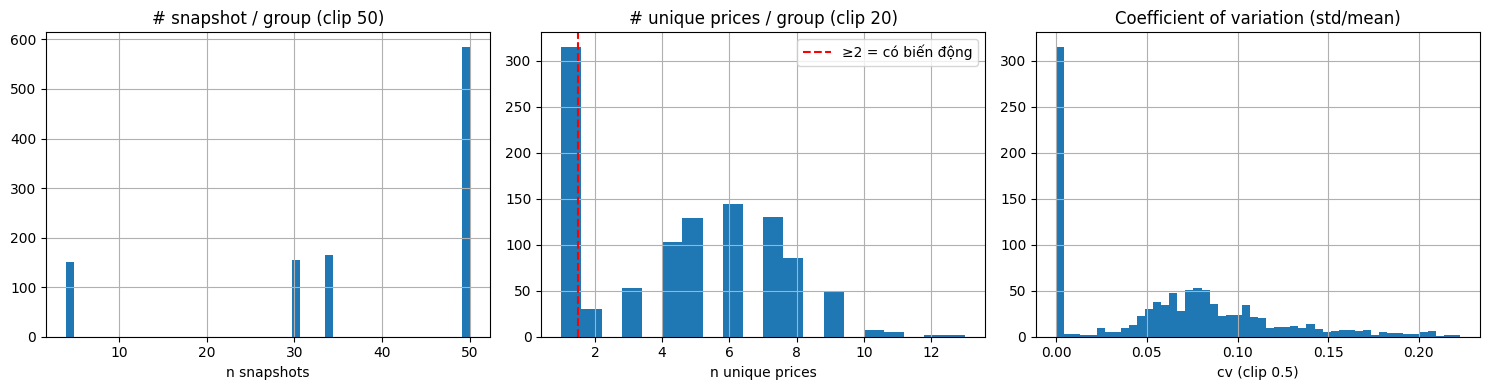

In [18]:
# Visualize: phân phối số snapshot và biến động giá
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

variation['n_snapshots'].clip(upper=50).hist(bins=50, ax=axes[0])
axes[0].set_title('# snapshot / group (clip 50)')
axes[0].set_xlabel('n snapshots')

variation['n_unique_prices'].clip(upper=20).hist(bins=20, ax=axes[1])
axes[1].set_title('# unique prices / group (clip 20)')
axes[1].set_xlabel('n unique prices')
axes[1].axvline(1.5, color='red', linestyle='--', label='≥2 = có biến động')
axes[1].legend()

variation['cv'].dropna().clip(upper=0.5).hist(bins=50, ax=axes[2])
axes[2].set_title('Coefficient of variation (std/mean)')
axes[2].set_xlabel('cv (clip 0.5)')

plt.tight_layout(); plt.show()

## 13. Booking signal — `did_book` events

**Why**: Bước 4 (demand model) build label `did_book = 1` khi `total_booked` tăng giữa 2 snapshot liên tiếp. Trước khi vào đó cần check trước:

- Tổng số event positive (`did_book == 1`) là bao nhiêu? → nếu quá ít → class imbalance gay gắt, phải dùng `class_weight='balanced'` hoặc resample.
- Có thấy event xảy ra ở nhiều `(hotel, room_type)` không, hay chỉ tập trung 1–2 loại phòng hot?

In [19]:
df_sorted = df.sort_values(['hotel_id', 'room_type_name', 'date', 'updated_date']).copy()
grp = df_sorted.groupby(['hotel_id', 'room_type_name', 'date'])

df_sorted['next_total_booked'] = grp['total_booked'].shift(-1)
df_sorted['delta_booked']      = df_sorted['next_total_booked'] - df_sorted['total_booked']
# Chỉ những dòng có "snapshot tiếp theo" mới có nhãn — dòng cuối mỗi group bị NaN
df_sorted['did_book'] = (df_sorted['delta_booked'] > 0).astype('Int64')
df_sorted.loc[df_sorted['next_total_booked'].isna(), 'did_book'] = pd.NA

labeled = df_sorted.dropna(subset=['did_book'])
pos = int((labeled['did_book'] == 1).sum())
neg = int((labeled['did_book'] == 0).sum())
total = pos + neg
print(f'Số dòng có label    : {total:,}')
print(f'did_book = 1 (book) : {pos:,} ({pos/total*100:.2f}%)')
print(f'did_book = 0 (idle) : {neg:,} ({neg/total*100:.2f}%)')

print('\nEvent count theo room_type:')
print(labeled.groupby('room_type_name')['did_book'].agg(['sum', 'count', 'mean']).round(3))

Số dòng có label    : 54,170
did_book = 1 (book) : 3,117 (5.75%)
did_book = 0 (idle) : 51,053 (94.25%)

Event count theo room_type:
                                         sum  count   mean
room_type_name                                            
Deluxe City View Room                    499  10834  0.046
Deluxe City View with banquette seating  462  10834  0.043
Deluxe with banquette seating            759  10834   0.07
Premier city view                        424  10834  0.039
Superior City View                       973  10834   0.09


## 14. Feasibility cho SARIMA — chiều dài series

**Why**: SARIMA cần series đủ dài để tách trend + seasonality. Rule-of-thumb: tối thiểu 2× chu kỳ seasonal (m=7 weekly → ≥14 ngày), thực tế nên ≥60–90 ngày để stable.

Đếm: per `(hotel, room_type)`, có bao nhiêu stay_date unique?

Phán đoán:
- ≥90 days mỗi series → SARIMA OK.
- 30–90 → biên giới, có thể phải dùng SES/Holt-Winters đơn giản hơn.
- <30 → quá ngắn, phải gộp theo `room_type_segment` (ROADMAP §3 Bước 3 caveat).

In [20]:
series_len = (latest.groupby(['hotel_id', 'room_type_name'])['date']
                    .nunique().rename('n_stay_dates').reset_index()
                    .sort_values('n_stay_dates', ascending=False))
print(series_len.to_string(index=False))

print('\nDistribution n_stay_dates per (hotel, room_type):')
print(series_len['n_stay_dates'].describe().round(1))

 hotel_id                          room_type_name  n_stay_dates
      956                   Deluxe City View Room           211
      956 Deluxe City View with banquette seating           211
      956           Deluxe with banquette seating           211
      956                       Premier city view           211
      956                      Superior City View           211

Distribution n_stay_dates per (hotel, room_type):
count      5.0
mean     211.0
std        0.0
min      211.0
25%      211.0
50%      211.0
75%      211.0
max      211.0
Name: n_stay_dates, dtype: float64


## 15. 📌 Insights — bullet list cho Bước 2

*Sau khi chạy hết notebook, điền dưới đây 5–8 insight. Đây chính là deliverable.*

**Schema / data quality**
- [ ] Số dòng / cột thực tế: ___
- [ ] Missing đáng kể ở cột: ___
- [ ] Duplicate logic key (`updated_date, hotel_id, room_type_name, date`): ___
- [ ] `price == 0` chiếm: ___ % → cần filter ở `clean()`.

**Cardinality**
- [ ] Số hotel: ___ → dropdown app có ___ lựa chọn.
- [ ] Số `(hotel, room_type)` cần fit SARIMA: ___

**Pattern**
- [ ] Weekly seasonality rõ / mờ: ___
- [ ] Holiday spike thấy ở: ___
- [ ] Lead_time distribution: tập trung ___ ngày, có tail đến ___ ngày.

**KEY: Biến động giá**
- [ ] % group có giá cố định (1 mức): ___ %
- [ ] % group có ≥3 mức giá: ___ %
- [ ] **Quyết định demand model**: (a) đủ signal → LogReg + LightGBM theo plan; (b) signal yếu → ghi caveat "predictive, not causal", giảm scope demand → chỉ làm baseline.

**SARIMA feasibility**
- [ ] Series ngắn nhất: ___ ngày → (đủ / không đủ) cho SARIMA.
- [ ] Nếu không đủ: gộp theo `room_type_segment` hoặc dùng Holt-Winters.

**Booking signal**
- [ ] Tỷ lệ `did_book = 1`: ___ % → (cân bằng / imbalanced, cần class_weight).

---

**Next step** → `notebooks/02_features.ipynb` + viết `src/features.build_features()`.